Mean Absolute Error:  0.025240476034544674
Mean Squared Error:  0.0010212231925729677
R2 Score :  0.9999999999967443
Model Saved Successfully!
[50001.01668125  3004.98771247  1504.03527496  1506.01012871
 20002.06481499  3003.98774459]


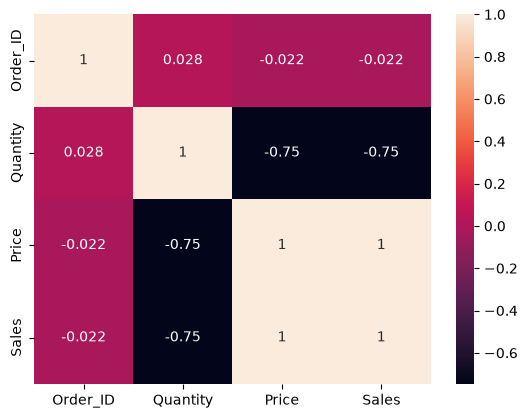

In [1]:
# project using MLR | seabon
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
url ="https://raw.githubusercontent.com/PDSE17/Ecommerce_Sales_Analysis/refs/heads/main/ecommerce_sales.csv"
df = pd.read_csv(url)

# ADDING A NEW COLUMN
df["Sales"] = df["Quantity"] + df["Price"]

# GRAPHS
sns.countplot(data=df, x="Category")
sns.barplot(data=df, x="City", y="Sales")
sns.histplot(df["Price"], kde=True)
sns.boxplot(data=df, x="Category", y="Sales")
sns.heatmap(df.corr(numeric_only=True),annot=True)

# ENCODE TEXT COLUMNS
df = pd.get_dummies(df, columns=["Product","Category","City","Month"], drop_first=True)


x = df.drop(["Sales"],axis=1)
y = df["Sales"]

# SPLIT DATASET
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# MULTIPLE LINEAR REGRESSION
model = LinearRegression()
model.fit(x_train, y_train)

# PREDICTION
y_pred = model.predict(x_test)

# EVALUATION
print("Mean Absolute Error: ",mean_absolute_error(y_test, y_pred))

print("Mean Squared Error: ",mean_squared_error(y_test, y_pred))

print("R2 Score : ",r2_score(y_test, y_pred))


# DUMP MODEL
import joblib
joblib.dump(model,"Sales_prediction_model.joblib")
print("Model Saved Successfully!")

# LOAD MODEL
loaded_model = joblib.load("Sales_prediction_model.joblib")

prediction = loaded_model.predict(x_test)

print(prediction)